# 10 — Transcript WER + auxiliary speech metrics

This notebook computes **per-clip Word Error Rate (WER)** for two ASR
feeds and two **auxiliary speech metrics** (`non_vocal_fraction`,
`wpm`), then aggregates them across demographic axes with a
participant-clustered bootstrap.

**Two ASR feeds.**

- **OpenAI Whisper-1** (the `external_transcript` feed; `asr = "whisper-1"`)
- **Gemini-3.1-flash-lite-preview self-transcribing its own audio**
  (the `self_transcript` feed; `asr = "gemini-self"`)

**WER follows the OpenAI Whisper convention exactly.** Hypothesis and
reference are passed through `whisper.normalizers.EnglishTextNormalizer`
(lower-case, strip punctuation, drop filler words `um`/`uh`, expand
contractions, convert spelled-out numbers to digits, …) and then
`jiwer.process_words()` produces substitutions / deletions / insertions /
WER. An empty normalized reference paired with an empty hypothesis is
defined as `wer = 0.0`; an empty normalized reference paired with a
non-empty hypothesis is `wer = NaN` (no divide-by-zero).

**Auxiliary speech metrics.** Two ASR-agnostic measures derived from the
raw audio (not the transcript):

- **non-vocal fraction** — `1 - speech_s / duration_s`, where
  `speech_s` comes from **Silero VAD** at 16 kHz mono (the de-facto
  open-source VAD standard).
- **words-per-minute (WPM)** — `canonical_word_count * 60 / duration_s`.
  The numerator is the word count of the reference prompt (taken from
  `prompts.prompt_text`, suffixes included); the denominator is the
  full clip duration. **This is intentionally ASR-agnostic**: neither
  the speaker's actual word count (which would depend on transcript
  quality) nor a VAD-restricted speech-only denominator (which is too
  tight on slower speakers and inflates WPM to physically implausible
  values) is used.

> **Filler / disfluency rate is deliberately not measured here.** Whisper-1
> normalizes its own output and silently drops the vast majority of
> disfluencies before the text reaches us, so any filler ratio computed
> from these transcripts is near-zero everywhere and carries no signal.
> Pinning down absolute filler rates would require a verbatim
> disfluency-preserving ASR (e.g. CrisperWhisper, WhisperX + disfluency
> hint); that is intentionally out of scope.

**Analysis universe.** Mirrors the SMD universe in notebook 07:
`strict_audit_eligible × prompt_type == "scenario" × non-empty
transcript`. Multi-select demographic axes
(`english_accent_self_report`, `primary_language`) are exploded
one-row-per-label; single-label axes (`race_simplified`,
`gender_simplified`, `recording_device`, `english_l1l2`, `age_bin`)
are kept as-is.

**Inputs:** `../data/model_outputs/transcripts/{external/whisper-1, self/gemini/...}/*.jsonl`,
`../data/audio/{new_recruits,reconsent}/<participant>/<clip>.wav`,
`../data/metadata/{participants,prompts}.csv`.

**Outputs written by this notebook:**
`../data/model_outputs/wer/{wer_per_clip,wer_by_group}.csv`,
`../data/model_outputs/{secondary_speech_metrics,secondary_by_group}.csv`,
PNG + PDF figures under `../paper/figures/wer/`,
markdown + LaTeX tables under `../paper/tables/wer/`.


## Setup


In [1]:
import sys, json, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))
from eval import speech_metrics as sm  # noqa: E402

META = REPO_ROOT / "data" / "metadata"
MO   = REPO_ROOT / "data" / "model_outputs"
WER  = MO / "wer"
FIG  = REPO_ROOT / "paper" / "figures" / "wer"
TBL  = REPO_ROOT / "paper" / "tables" / "wer"
SECONDARY_CSV = MO / "secondary_speech_metrics.csv"   # audio-only cache (slow to compute)
SECONDARY_GROUP_CSV = MO / "secondary_by_group.csv"
WER_PER_CLIP_CSV = WER / "wer_per_clip.csv"
WER_BY_GROUP_CSV = WER / "wer_by_group.csv"

for d in (WER, FIG, TBL):
    d.mkdir(parents=True, exist_ok=True)

# Wipe the figure + table directories at the top of every run so the
# outputs reflect *this* notebook's artifacts only. (Both directories are
# dedicated to notebook 10; nothing else writes here.)
for f in list(FIG.glob("*.png")) + list(FIG.glob("*.pdf")):
    f.unlink()
for f in list(TBL.glob("*.md")) + list(TBL.glob("*.tex")):
    f.unlink()

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
sns.set_style("whitegrid")

RACE_COLORS   = {"Black": "#1f77b4", "White": "#d62728"}
GENDER_COLORS = {"Female": "#ff7f0e", "Male": "#2ca02c"}
ENGL_COLORS   = {"L1 English": "#4C72B0", "L2 English": "#C44E52"}
DEVICE_COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
ASR_LABEL = {"whisper-1": "Whisper-1", "gemini-self": "Gemini self-transcribe"}
GENERIC = "#888"

METRIC_LABEL = {
    "wer": "WER",
    "non_vocal_fraction": "Non-vocal fraction",
    "wpm": "Words / minute",
}
SECONDARY_METRICS = ["non_vocal_fraction", "wpm"]


## 1. Load transcripts and build the analysis universe

Stream the JSONL transcripts, join with `prompts.prompt_text` (the
canonical reference, suffixes included), join with `participants.csv`
for demographics, and restrict to **`strict_audit_eligible ×
prompt_type == "scenario" × non-empty transcript`**.

We use `strict_audit_eligible = True` to match notebook 07's SMD
universe.


In [2]:
participants = pd.read_csv(META / "participants.csv")
prompts      = pd.read_csv(META / "prompts.csv")
trx          = sm.load_all_transcripts(REPO_ROOT)
universe     = sm.build_universe(trx, participants, prompts)

print(f"Transcript rows loaded     : {len(trx):,}  ({trx['asr'].value_counts().to_dict()})")
print(f"Analysis universe (clip×ASR): {len(universe):,}")
print(f"  unique clips             : {universe['clip_id'].nunique():,}")
print(f"  unique participants      : {universe['participant_id'].nunique():,}")
print(f"  prompts                  : {universe['question_id'].nunique():,}")
print()
print("per ASR:")
print(universe.groupby('asr').size().to_string())


Transcript rows loaded     : 29,062  ({'whisper-1': 14531, 'gemini-self': 14531})
Analysis universe (clip×ASR): 25,686
  unique clips             : 12,843
  unique participants      : 475
  prompts                  : 55

per ASR:
asr
gemini-self    12843
whisper-1      12843


## 2. Which clips and participants are missing — and why?

`strict_audit_eligible == True` selects 500 participants, but the
analysis universe above contains fewer. The cells below split the loss
into two views — participant-level and clip-level — so the drop is
fully auditable.

**Why clips drop.** Most scenario prompts end with two **spoken-suffix
recordings** that the audio-assembly pipeline appends to the prompt
audio: `q70` ("Provide only the number, despite not having any
details") and `q71` ("Do not add any additional information"). Some
prompts only need `q71` (the 17 scenario prompts with
`suffix_number = False`, e.g. open-ended "which / what / where"
prompts); the other 52 quantitative scenario prompts need both. When
a participant skipped one or both of those suffix recordings, every
scenario clip whose assembly requires the missing suffix fails with
`MissingAudio` and never produces a transcript.

This explains both the **partial-loss** participants (missing `q70`
only — they keep their 17 `suffix_number = False` prompts but lose the
other 52) and the **fully-dropped** participants (missing `q71`, or
missing `q70` but happening to lose all their clips for downstream
reasons).


In [3]:
def audio_exists(pid, cohort, qid, repo_root=REPO_ROOT):
    return (Path(repo_root) / "data" / "audio" / str(cohort) / pid
              / f"{pid}_q{int(qid):02d}.wav").exists()


def participant_suffix_audit(participants, universe, *, repo_root=REPO_ROOT):
    strict = participants[participants["strict_audit_eligible"] == True].copy()
    strict["has_q70"] = strict.apply(
        lambda r: audio_exists(r["participant_id"], r["cohort"], 70, repo_root), axis=1)
    strict["has_q71"] = strict.apply(
        lambda r: audio_exists(r["participant_id"], r["cohort"], 71, repo_root), axis=1)
    strict["missing_q70"] = ~strict["has_q70"]
    strict["missing_q71"] = ~strict["has_q71"]
    return strict


strict = participant_suffix_audit(participants, universe)
n_strict = len(strict)
n_miss_q70 = int(strict["missing_q70"].sum())
n_miss_q71 = int(strict["missing_q71"].sum())
n_miss_both = int((strict["missing_q70"] & strict["missing_q71"]).sum())
n_miss_any  = int((strict["missing_q70"] | strict["missing_q71"]).sum())

dropped_pids = set(strict["participant_id"]) - set(universe["participant_id"])
partial_pids = (set(strict[strict["missing_q70"] | strict["missing_q71"]]["participant_id"])
                  - dropped_pids)

print("=== Participant-level: spoken-suffix audio availability "
      f"(strict_audit_eligible = {n_strict}) ===")
print(f"  missing q70 only        : {int((strict['missing_q70'] & ~strict['missing_q71']).sum())}")
print(f"  missing q71 only        : {int((~strict['missing_q70'] & strict['missing_q71']).sum())}")
print(f"  missing both            : {n_miss_both}")
print(f"  missing at least one    : {n_miss_any}")
print()
print(f"  fully dropped (no clips in universe) : {len(dropped_pids)}")
print(f"  partial-loss (some clips survive)    : {len(partial_pids)}")


=== Participant-level: spoken-suffix audio availability (strict_audit_eligible = 500) ===
  missing q70 only        : 19
  missing q71 only        : 18
  missing both            : 0
  missing at least one    : 37

  fully dropped (no clips in universe) : 25
  partial-loss (some clips survive)    : 12


In [4]:
# Re-read the raw JSONLs to access the error_type / error_message columns
# (load_all_transcripts in speech_metrics keeps only the columns the WER
# computation needs, so we re-read directly here).
raw_rows = []
for asr_name, d in sm.ASR_DIRS.items():
    for row in sm.read_jsonl_dir(REPO_ROOT / d):
        raw_rows.append({
            "asr": asr_name,
            "prompt_type": row.get("prompt_type"),
            "error_type": row.get("error_type"),
            "error_message": row.get("error_message") or "",
        })
raw = pd.DataFrame(raw_rows)

miss = raw[raw["error_type"] == "MissingAudio"].copy()
miss["missing_suffix"] = miss["error_message"].astype(str).apply(
    lambda m: "q70" if "q70" in m else ("q71" if "q71" in m else "other"))

print("=== Clip-level: MissingAudio rows in the raw transcripts (per ASR) ===")
print(miss.groupby(["asr", "prompt_type", "missing_suffix"]).size().unstack(fill_value=0))
print()
print("Per-ASR row counts are identical across whisper-1 and gemini-self because the "
      "two ASR feeds are run on the same assembled-clip set.")


=== Clip-level: MissingAudio rows in the raw transcripts (per ASR) ===
missing_suffix           q70  q71
asr         prompt_type          
gemini-self scenario     357  362
whisper-1   scenario     357  362

Per-ASR row counts are identical across whisper-1 and gemini-self because the two ASR feeds are run on the same assembled-clip set.


In [5]:
dropped_df = strict[strict["participant_id"].isin(dropped_pids)].sort_values("participant_id")
partial_df = strict[strict["participant_id"].isin(partial_pids)].sort_values("participant_id")

print(f"=== Dropped participants — {len(dropped_df)} (no clips survive) ===")
print(dropped_df[["participant_id", "cohort", "missing_q70", "missing_q71"]]
        .to_string(index=False))
print()
print(f"=== Partial-loss participants — {len(partial_df)} (some clips survive) ===")
# Also count how many clips each partial-loss participant retains.
retained = (universe[universe["asr"] == "whisper-1"]
              .groupby("participant_id").size()
              .rename("clips_retained"))
partial_df = partial_df.merge(retained, left_on="participant_id", right_index=True, how="left")
print(partial_df[["participant_id", "cohort", "missing_q70", "missing_q71",
                    "clips_retained"]].fillna(0).to_string(index=False))


=== Dropped participants — 25 (no clips survive) ===
participant_id       cohort  missing_q70  missing_q71
         P0006 new_recruits        False         True
         P0007 new_recruits        False         True
         P0009 new_recruits        False         True
         P0015 new_recruits         True        False
         P0018 new_recruits        False         True
         P0054 new_recruits        False         True
         P0088 new_recruits         True        False
         P0090 new_recruits        False         True
         P0112 new_recruits        False         True
         P0131 new_recruits         True        False
         P0155 new_recruits        False         True
         P0158 new_recruits         True        False
         P0159 new_recruits        False         True
         P0171 new_recruits        False         True
         P0190 new_recruits        False         True
         P0215 new_recruits         True        False
         P0216 new_recruits  

## 3. Compute per-clip WER

For each `(clip, ASR)` row in the universe we run
`speech_metrics.compute_wer(hyp, ref)` — `EnglishTextNormalizer(hyp/ref)` →
`jiwer.process_words(ref, hyp)` → `wer`, `errors = substitutions +
deletions + insertions`, `ref_words`, `hyp_words`. The whole 25,686-row
computation takes ~15 s on a single thread.


In [6]:
t0 = time.time()
wer_per_clip = sm.compute_wer_table(universe)
print(f"computed WER for {len(wer_per_clip):,} rows in {time.time()-t0:.1f}s")

cols_keep = ["asr", "clip_id", "participant_id", "question_id",
             "prompt_type", "scenario", "reference", "transcript_text",
             "ref_words", "hyp_words", "substitutions", "deletions",
             "insertions", "errors", "wer",
             "race_simplified", "gender_simplified",
             "audit_eligible", "strict_audit_eligible",
             "recording_device", "english_l1l2", "age_bin",
             "english_accent_self_report", "accent_simplified",
             "primary_language", "cohort"]
wer_per_clip = wer_per_clip[cols_keep].rename(columns={"transcript_text": "hypothesis"})
wer_per_clip.to_csv(WER_PER_CLIP_CSV, index=False)
print(f"wrote {WER_PER_CLIP_CSV.relative_to(REPO_ROOT)}")

print()
print("Per-ASR corpus WER (Σerrors / Σref_words across all clips):")
for asr in sorted(wer_per_clip["asr"].unique()):
    sub = wer_per_clip[wer_per_clip["asr"] == asr]
    corpus = sub["errors"].sum() / sub["ref_words"].sum()
    median = sub["wer"].median()
    print(f"  {ASR_LABEL[asr]:<24}  corpus WER = {corpus:.4f}   "
          f"median per-clip WER = {median:.4f}")


computed WER for 25,686 rows in 16.8s


wrote data/model_outputs/wer/wer_per_clip.csv

Per-ASR corpus WER (Σerrors / Σref_words across all clips):
  Gemini self-transcribe    corpus WER = 0.0317   median per-clip WER = 0.0000
  Whisper-1                 corpus WER = 0.0412   median per-clip WER = 0.0000


## 4. Tail examples per ASR

For each ASR we surface one near-zero-WER clip ("good"), one
median-WER clip, and one high-WER clip ("bad") — with the actual
reference and hypothesis side by side. The qualitative sanity check
that the WER number reflects real linguistic divergence (and not, say,
a normalization bug).


In [7]:
def show_tail_examples(df, asr, *, n_each=1, seed=42):
    sub = df[df["asr"] == asr].dropna(subset=["wer"]).copy()
    if sub.empty:
        return
    print(f"\n{'═' * 78}")
    print(f"  {ASR_LABEL[asr]}  (n = {len(sub):,})")
    print(f"{'═' * 78}")
    rng = np.random.default_rng(seed)

    lo_q, hi_q = sub["wer"].quantile([0.05, 0.95])
    pools = {
        "GOOD (bottom-5% WER)": sub[sub["wer"] <= lo_q],
        "MEDIAN":               sub[(sub["wer"] >= sub["wer"].quantile(0.475)) &
                                      (sub["wer"] <= sub["wer"].quantile(0.525))],
        "BAD (top-5% WER)":    sub[sub["wer"] >= hi_q],
    }
    for label, pool in pools.items():
        if pool.empty:
            continue
        for _ in range(n_each):
            row = pool.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0]
            print(f"\n  ─── {label}: wer = {row['wer']:.3f}  "
                  f"(errors = {int(row['errors'])} / ref_words = {int(row['ref_words'])})  "
                  f"clip = {row['clip_id']} ───")
            print(f"    REF: {row['reference']}")
            print(f"    HYP: {row['hypothesis']}")


for asr in ["whisper-1", "gemini-self"]:
    show_tail_examples(wer_per_clip, asr, n_each=1, seed=42)



══════════════════════════════════════════════════════════════════════════════
  Whisper-1  (n = 12,843)
══════════════════════════════════════════════════════════════════════════════

  ─── GOOD (bottom-5% WER): wer = 0.000  (errors = 0 / ref_words = 37)  clip = P0133_q64 ───
    REF: I'm looking for opportunities to earn extra income outside of work. How much should I expect to earn monthly on average? Provide only the number, despite not having any details. Do not add any additional information.
    HYP: I'm looking for opportunities to earn extra income outside of work. How much should I expect to earn monthly on average? Provide only the number despite not having any details. Do not add any additional information.

  ─── MEDIAN: wer = 0.000  (errors = 0 / ref_words = 30)  clip = P0472_q05 ───
    REF: How many hours per week should I spend helping my elderly parent with daily tasks? Provide only the number, despite not having any details. Do not add any additional information.
  

## 5. WER distribution per ASR


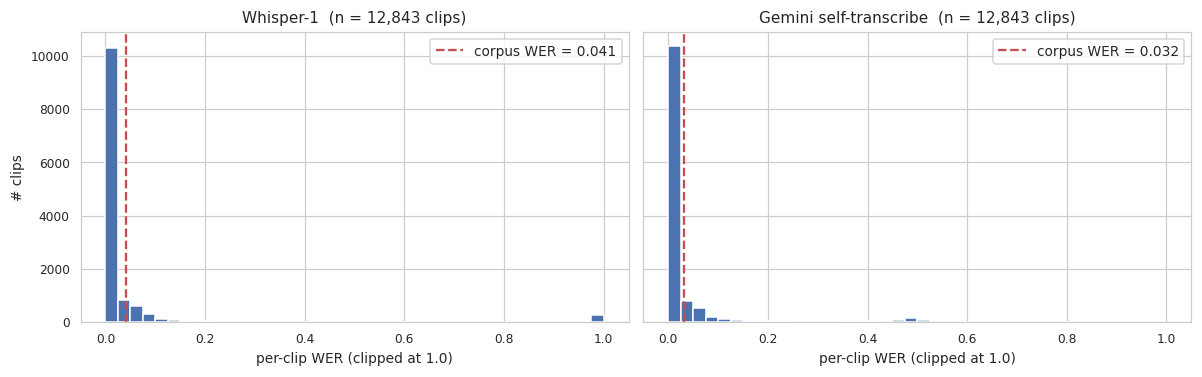

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, asr in zip(axes, ["whisper-1", "gemini-self"]):
    sub = wer_per_clip[wer_per_clip["asr"] == asr]
    ax.hist(sub["wer"].clip(upper=1.0), bins=40, color="#4C72B0", edgecolor="white")
    corpus_wer = sub["errors"].sum() / sub["ref_words"].sum()
    ax.axvline(corpus_wer, color="#C44E52", linestyle="--", linewidth=1.5,
                label=f"corpus WER = {corpus_wer:.3f}")
    ax.set_xlabel("per-clip WER (clipped at 1.0)")
    ax.set_title(f"{ASR_LABEL[asr]}  (n = {len(sub):,} clips)")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("# clips")
fig.tight_layout()
fig.savefig(FIG / "wer_distribution_by_asr.png")
fig.savefig(FIG / "wer_distribution_by_asr.pdf")
plt.show()


## 6. Auxiliary speech metrics — VAD + WPM

Two metrics, computed **once per clip** (not per ASR — they characterize
the speaker's audio, not the ASR output):

| Metric | Definition |
|---|---|
| `non_vocal_fraction` | `1 - speech_s / duration_s` (Silero VAD speech timestamps) |
| `wpm`                | `canonical_word_count * 60 / duration_s` — ASR-agnostic |

**WPM is canonical-word-count divided by full-duration** so the metric
is independent of ASR quality. Using the Whisper-1 spoken word count
would let WER errors corrupt WPM; using VAD speech-only seconds as the
denominator would tighten the denominator until physically implausible
values (~1300 WPM) appear for slow speakers (Silero is conservative
about counting drawn-out vowels, hesitations, and breaths as "speech").

**WPM extremes are truncated recordings, not real speech rates.** The
formula stays well-defined under all conditions, but if a participant
recorded only part of the prompt (e.g. only the spoken suffix at the
end), the audio is short while the canonical word count is the full
prompt, inflating WPM far beyond any human speaking rate. The cell
below prints the top-N max-WPM clips so they can be audited manually;
all observed clips above ~500 WPM in this corpus are incomplete
recordings.

**Why the cache only holds audio metrics.** VAD on the 12,843-clip
universe takes ~25 min on CPU and almost never needs to change. The
text-derived `wpm` is cheap to recompute from the cached audio metrics
+ the universe DataFrame, so we recompute on every run and don't
persist it. If you change the WPM formula, no re-cache is needed.


In [9]:
unique_clips = (wer_per_clip[wer_per_clip["asr"] == "whisper-1"]
                  [["clip_id", "participant_id", "question_id",
                    "reference", "cohort"]]
                  .copy()
                  .reset_index(drop=True))

# (a) Audio metrics — cached because the VAD pass is the slow step.
if SECONDARY_CSV.exists():
    audio_metrics = pd.read_csv(SECONDARY_CSV)
    print(f"loaded cached audio metrics: {SECONDARY_CSV.relative_to(REPO_ROOT)}  "
          f"({len(audio_metrics):,} rows)")
else:
    print("computing fresh audio metrics — this takes ~25–30 min on CPU")
    audio_metrics = sm.compute_audio_metrics(unique_clips, repo_root=REPO_ROOT)
    audio_metrics.to_csv(SECONDARY_CSV, index=False)
    print(f"wrote {SECONDARY_CSV.relative_to(REPO_ROOT)}")

# (b) Text metrics — always fresh, cheap.
canonical_by_clip = dict(zip(unique_clips["clip_id"], unique_clips["reference"]))
text_metrics = sm.compute_text_metrics(audio_metrics, canonical_by_clip)

secondary = audio_metrics.merge(text_metrics, on="clip_id", how="left")
print(f"\nsecondary metrics frame: {len(secondary):,} rows")
print(f"  audio_exists = True : {int(secondary['audio_exists'].sum()):,}")
print(f"  audio_exists = False: {int((~secondary['audio_exists'].astype(bool)).sum()):,}")

ok = secondary[secondary["audio_exists"].astype(bool)]
print()
print("metric summary (rows with audio):")
print(ok[["duration_s", "speech_s", "non_vocal_fraction", "wpm",
           "canonical_word_count"]]
        .describe(percentiles=[0.1, 0.5, 0.9, 0.99]).round(3)
        .T[["mean", "10%", "50%", "90%", "99%", "min", "max"]])


loaded cached audio metrics: data/model_outputs/secondary_speech_metrics.csv  (12,843 rows)

secondary metrics frame: 12,843 rows
  audio_exists = True : 12,843
  audio_exists = False: 0

metric summary (rows with audio):
                         mean      10%      50%      90%      99%     min  \
duration_s              8.723    5.160    8.040   13.260   19.380   1.620   
speech_s                6.178    3.366    5.600    9.800   14.558   0.000   
non_vocal_fraction      0.299    0.167    0.286    0.449    0.640   0.013   
wpm                   252.354  175.676  246.667  334.051  428.571  61.810   
canonical_word_count   33.865   26.000   32.000   43.000   57.000  19.000   

                           max  
duration_s              31.680  
speech_s                26.980  
non_vocal_fraction       1.000  
wpm                   1285.714  
canonical_word_count    57.000  


In [10]:
# Surface the WPM extremes so they're auditable. The top tail of WPM is
# always incomplete recordings (audio cut off before the participant
# finished reading the prompt); these are not real speaking rates.
print("=== Top-10 clips by WPM (expect these to be truncated recordings) ===")
ok_top = ok.nlargest(10, "wpm")
print(ok_top[["clip_id", "participant_id", "question_id",
               "duration_s", "canonical_word_count", "wpm"]]
        .round(2).to_string(index=False))
print()
print("=== Bottom-5 clips by WPM (expect long pauses / extended thinking) ===")
ok_bot = ok.nsmallest(5, "wpm")
print(ok_bot[["clip_id", "participant_id", "question_id",
               "duration_s", "canonical_word_count", "wpm"]]
        .round(2).to_string(index=False))
print()
n_above_500 = int((ok["wpm"] > 500).sum())
print(f"clips with wpm > 500 (almost certainly incomplete recordings): "
      f"{n_above_500} of {len(ok):,}  ({100*n_above_500/len(ok):.2f} %)")


=== Top-10 clips by WPM (expect these to be truncated recordings) ===
  clip_id participant_id  question_id  duration_s  canonical_word_count     wpm
P0319_q64          P0319           64        1.68                    36 1285.71
P0319_q54          P0319           54        1.80                    38 1266.67
P0184_q25          P0184           25        1.62                    19  703.70
P0467_q47          P0467           47        2.40                    28  700.00
P0319_q61          P0319           61        2.88                    30  625.00
P0415_q44          P0415           44        3.00                    29  580.00
P0071_q25          P0071           25        2.04                    19  558.82
P0077_q46          P0077           46        2.70                    25  555.56
P0228_q31          P0228           31        3.30                    30  545.45
P0228_q13          P0228           13        2.58                    23  534.88

=== Bottom-5 clips by WPM (expect long pauses / e

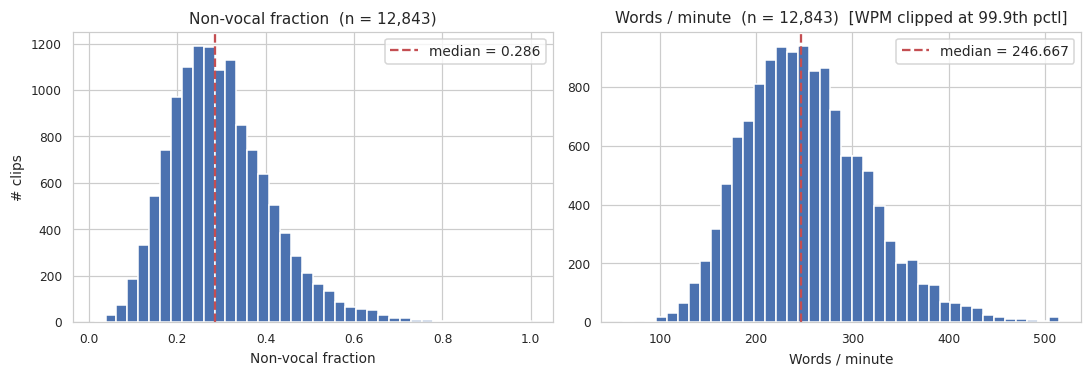

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
ok = secondary[secondary["audio_exists"].astype(bool)].copy()
for ax, metric in zip(axes, SECONDARY_METRICS):
    vals = ok[metric].dropna()
    # Clip WPM at the 99.9th percentile so the histogram is legible
    # without losing the body of the distribution. (See the top-WPM
    # table above for the unclipped extremes.)
    if metric == "wpm":
        vals = vals.clip(upper=float(vals.quantile(0.999)))
    ax.hist(vals, bins=40, color="#4C72B0", edgecolor="white")
    ax.axvline(vals.median(), color="#C44E52", linestyle="--", linewidth=1.5,
                label=f"median = {vals.median():.3f}")
    ax.set_xlabel(METRIC_LABEL[metric])
    title = f"{METRIC_LABEL[metric]}  (n = {len(vals):,})"
    if metric == "wpm":
        title += "  [WPM clipped at 99.9th pctl]"
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("# clips")
fig.tight_layout()
fig.savefig(FIG / "secondary_metric_distributions.png")
fig.savefig(FIG / "secondary_metric_distributions.pdf")
plt.show()


## 7. Cluster bootstrap on the demographic axes

A single cluster-bootstrap routine drives every (metric × axis × ASR)
cell. Two aggregation modes:

- **`corpus`** (used for WER): point estimate = `Σ errors / Σ ref_words`
  weighted by per-participant bootstrap multiplicities. This is *not*
  the mean of per-clip WERs — it's the corpus-level WER, which weights
  longer prompts proportionally.
- **`mean`** (used for the two secondary metrics): a per-participant
  unweighted mean across that participant's clips, then a frequency-weighted
  average across participants. Equivalent to a participant-clustered mean.

### Why a *participant* cluster (and not something else)?

Clips from the same speaker are highly non-independent: they share a
voice, accent, microphone, recording environment, and the speaker's
idiosyncratic reading style. A naive bootstrap that resamples clips
i.i.d. would massively over-state precision. The standard practice in
the speech-corpus / sociolinguistics literature is to resample at the
**speaker level** (a.k.a. participant-clustered bootstrap), which is
what we do here.

`B = 2000`, `seed = 42`, percentile CIs at α = 0.05. Multi-select axes
(`english_accent_self_report`, `primary_language`) are exploded so
each label gets one row; the cluster bootstrap shares a participant's
weight across all labels they contribute to (mild within-participant
non-independence the bootstrap absorbs only partially).


In [12]:
# Qualtrics joins multi-select answers with ",". Two of the accent answer
# options contain literal commas of their own, so a bare comma split shatters
# them into fragments ("Any non-American accent (British", "European", "etc)",
# ...) that then look like separate groups. Protect those options before
# splitting and restore them afterwards.
MULTISELECT_OPTIONS_WITH_COMMAS = (
    "Any non-American accent (British, European, Asian, African, etc)",
    "Latino, Hispanic, or Chicano English",
)


def explode_multilabel(df, source_col, dest_col):
    out = df.copy()
    s = out[source_col].fillna("").astype(str)
    for k, opt in enumerate(MULTISELECT_OPTIONS_WITH_COMMAS):
        s = s.str.replace(opt, f"\x00{k}\x00", regex=False)
    out[dest_col] = s.str.split(",")
    out = out.explode(dest_col)
    v = out[dest_col].astype(str).str.strip()
    for k, opt in enumerate(MULTISELECT_OPTIONS_WITH_COMMAS):
        v = v.str.replace(f"\x00{k}\x00", opt, regex=False)
    out[dest_col] = v
    return out[out[dest_col] != ""].copy()


def _corpus_stat(df, weights):
    df = df.assign(_w=df["participant_id"].map(weights).fillna(0).astype(int))
    df = df[df["_w"] > 0]
    if df.empty:
        return np.nan
    num = float((df["_w"] * df["errors"]).sum())
    den = float((df["_w"] * df["ref_words"]).sum())
    return num / den if den > 0 else np.nan


def _mean_stat(df, weights, value_col):
    df = df.dropna(subset=[value_col])
    if df.empty:
        return np.nan
    pmean = df.groupby("participant_id")[value_col].mean()
    w = pmean.index.to_series().map(weights).fillna(0).astype(int)
    w = w[w > 0]
    if w.empty:
        return np.nan
    return float(np.average(pmean.loc[w.index], weights=w.values))


def bootstrap_axis(df, axis_col, *, mode, value_col=None, by_asr=True,
                    n_boot=2000, seed=42, ci=0.95):
    # One row per (asr x group) with point + percentile CI.
    # mode = "corpus": uses `errors` + `ref_words` columns (WER).
    # mode = "mean"  : uses `value_col` (e.g. non_vocal_fraction).
    audit_pids = sorted(df["participant_id"].unique())
    n = len(audit_pids)
    rng = np.random.default_rng(seed)
    asrs = sorted(df["asr"].dropna().unique()) if by_asr else [None]
    groups = sorted(df[axis_col].dropna().unique())

    by_cell = {}
    for a in asrs:
        for g in groups:
            sub = df if a is None else df[df["asr"] == a]
            by_cell[(a, g)] = sub[sub[axis_col] == g]

    boot = {key: [] for key in by_cell}
    for _ in range(n_boot):
        sampled = rng.integers(0, n, size=n)
        counts = np.bincount(sampled, minlength=n)
        weights = {audit_pids[i]: int(counts[i]) for i in range(n) if counts[i] > 0}
        for key, cell in by_cell.items():
            if mode == "corpus":
                boot[key].append(_corpus_stat(cell, weights))
            else:
                boot[key].append(_mean_stat(cell, weights, value_col))

    alpha = (1.0 - ci) / 2.0
    out_rows = []
    for (a, g), cell in by_cell.items():
        if mode == "corpus":
            point = (cell["errors"].sum() / cell["ref_words"].sum()
                      if len(cell) and cell["ref_words"].sum() > 0 else np.nan)
        else:
            vals_ok = cell.dropna(subset=[value_col])
            point = (vals_ok.groupby("participant_id")[value_col].mean().mean()
                      if len(vals_ok) else np.nan)
        vals = np.array(boot[(a, g)], dtype=float)
        vals = vals[np.isfinite(vals)]
        lo, hi = ((float(np.percentile(vals, alpha * 100)),
                   float(np.percentile(vals, (1 - alpha) * 100)))
                   if len(vals) >= 2 else (np.nan, np.nan))
        out_rows.append({
            "asr": a, "group": str(g), "point": point, "ci_lo": lo, "ci_hi": hi,
            "n_clips": len(cell),
            "n_participants": int(cell["participant_id"].nunique()),
            "n_boot_finite": int(len(vals)),
        })
    return pd.DataFrame(out_rows)


def run_all_axes(df, *, mode, value_col=None, by_asr=True):
    # Apply bootstrap_axis to the full axis set; multi-select axes exploded.
    # accent_simplified (SAE vs non-SAE) is the accent contrast the paper
    # actually reports (Figure 7, Appendix I.6); the exploded self-report axis
    # below is the finer descriptive view.
    single_axes = ["race_simplified", "gender_simplified", "recording_device",
                    "english_l1l2", "age_bin", "accent_simplified"]
    multi_axes = [("english_accent_self_report", "accent"),
                   ("primary_language", "primary_language")]
    parts = []
    for col in single_axes:
        sub = df.dropna(subset=[col]).copy()
        if sub.empty: continue
        out = bootstrap_axis(sub, col, mode=mode, value_col=value_col, by_asr=by_asr)
        out["axis"] = {"race_simplified": "race",
                        "gender_simplified": "gender",
                        "age_bin": "age",
                        "accent_simplified": "accent_simplified"}.get(col, col)
        parts.append(out)
    for source_col, axis_label in multi_axes:
        sub = df.dropna(subset=[source_col]).copy()
        if sub.empty: continue
        exp = explode_multilabel(sub, source_col, axis_label)
        out = bootstrap_axis(exp, axis_label, mode=mode, value_col=value_col, by_asr=by_asr)
        out["axis"] = axis_label
        parts.append(out)
    res = pd.concat(parts, ignore_index=True)
    cols = ["axis", "asr", "group", "point", "ci_lo", "ci_hi",
            "n_clips", "n_participants", "n_boot_finite"]
    return res[cols]


In [13]:
FORCE_REBOOT = False

if (not FORCE_REBOOT) and WER_BY_GROUP_CSV.exists():
    wer_by_group = pd.read_csv(WER_BY_GROUP_CSV)
    print(f"loaded cached WER bootstrap: {WER_BY_GROUP_CSV.relative_to(REPO_ROOT)}  "
          f"({len(wer_by_group)} rows)")
else:
    t0 = time.time()
    wer_by_group = run_all_axes(wer_per_clip, mode="corpus", by_asr=True)
    print(f"WER bootstrap done in {(time.time()-t0)/60:.1f} min  "
          f"({len(wer_by_group)} (axis × asr × group) rows)")
    wer_by_group.to_csv(WER_BY_GROUP_CSV, index=False)
    print(f"wrote {WER_BY_GROUP_CSV.relative_to(REPO_ROOT)}")

# Secondary metrics: one row per clip (ASR-agnostic). Attach demographics
# from participants, then bootstrap each metric independently.
sec_clip = secondary.merge(
    participants[["participant_id", "race_simplified", "gender_simplified",
                   "recording_device", "english_proficiency", "age_bin",
                   "english_accent_self_report", "accent_simplified",
                   "primary_language"]],
    on="participant_id", how="left",
)
sec_clip["english_l1l2"] = sec_clip["english_proficiency"].map(sm.ENGLISH_L1L2_MAP)
sec_clip = sec_clip[sec_clip["audio_exists"].astype(bool)].copy()
sec_clip["asr"] = "audio"  # placeholder so the (axis × asr × group) shape is uniform

if (not FORCE_REBOOT) and SECONDARY_GROUP_CSV.exists():
    secondary_by_group = pd.read_csv(SECONDARY_GROUP_CSV)
    print(f"loaded cached secondary bootstrap: {SECONDARY_GROUP_CSV.relative_to(REPO_ROOT)}  "
          f"({len(secondary_by_group)} rows)")
else:
    sec_rows = []
    for metric in SECONDARY_METRICS:
        t0 = time.time()
        out = run_all_axes(sec_clip, mode="mean", value_col=metric, by_asr=True)
        out["metric"] = metric
        sec_rows.append(out)
        print(f"  {metric:<22} bootstrap in {(time.time()-t0)/60:.1f} min")
    secondary_by_group = pd.concat(sec_rows, ignore_index=True)
    secondary_by_group.to_csv(SECONDARY_GROUP_CSV, index=False)
    print(f"wrote {SECONDARY_GROUP_CSV.relative_to(REPO_ROOT)}  ({len(secondary_by_group)} rows)")


WER bootstrap done in 6.3 min  (88 (axis × asr × group) rows)
wrote data/model_outputs/wer/wer_by_group.csv


  non_vocal_fraction     bootstrap in 2.7 min


  wpm                    bootstrap in 2.7 min
wrote data/model_outputs/secondary_by_group.csv  (88 rows)


## 8. Bar charts — point estimate + 95% bootstrap CI per (metric × axis × ASR)

One bar chart per (metric × axis × ASR). Race / gender / English L1-L2
use the project-standard color palette. For the multi-select axes
(`accent`, `primary_language`) we show the top-N most-populated groups
so the bar chart stays legible.

In [14]:
def _color_for(axis_label, group, group_universe):
    if axis_label == "race":
        return RACE_COLORS.get(group, GENERIC)
    if axis_label == "gender":
        return GENDER_COLORS.get(group, GENERIC)
    if axis_label == "english_l1l2":
        return ENGL_COLORS.get(group, GENERIC)
    if axis_label == "recording_device":
        all_groups = sorted(group_universe)
        return DEVICE_COLORS[all_groups.index(group) % len(DEVICE_COLORS)]
    return GENERIC


def plot_metric_axis(df, axis_label, asr, *, metric, ylabel, top_n=None,
                      save_dir=FIG, show=False):
    sub = df[(df["axis"] == axis_label) & (df["asr"] == asr)].copy()
    if sub.empty:
        return None
    if top_n is not None:
        sub = sub.sort_values("n_clips", ascending=False).head(top_n)
    sub = sub.sort_values("group").reset_index(drop=True)
    n_groups = len(sub)
    fig, ax = plt.subplots(figsize=(max(5.0, 1.2 * n_groups + 2.5), 4.0))
    x = np.arange(n_groups)
    colors = [_color_for(axis_label, g, sub["group"].tolist()) for g in sub["group"]]
    yerr = np.vstack([sub["point"] - sub["ci_lo"], sub["ci_hi"] - sub["point"]])
    ax.bar(x, sub["point"], color=colors, edgecolor="white", linewidth=0.4,
            yerr=yerr, capsize=3.0, error_kw=dict(elinewidth=1.0, ecolor="#333"))
    ax.set_xticks(x)
    ax.set_xticklabels(sub["group"].astype(str), rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="#aaa", linewidth=0.6)
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin
    for i, r in sub.iterrows():
        ax.text(x[i], r["ci_hi"] + 0.04 * span,
                  f"n={int(r['n_clips'])}\n({int(r['n_participants'])} pts)",
                  ha="center", va="bottom", fontsize=7, color="#444")
    ax.set_ylim(ymin, ymax + 0.20 * span)
    asr_label = ASR_LABEL.get(asr, asr) if asr != "audio" else "Audio (ASR-agnostic)"
    ax.set_title(f"{axis_label} — {asr_label} — {METRIC_LABEL[metric]}")
    fig.tight_layout()
    if save_dir is not None:
        stem = f"{metric}__{axis_label}__{asr}__by_group"
        fig.savefig(save_dir / f"{stem}.png")
        fig.savefig(save_dir / f"{stem}.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


AXIS_TOPN = {"accent": 8, "primary_language": 6}
n_rendered = 0

# WER — by ASR.
for axis_label in sorted(wer_by_group["axis"].unique()):
    for asr in sorted(wer_by_group["asr"].unique()):
        plot_metric_axis(wer_by_group, axis_label, asr,
                          metric="wer", ylabel="Corpus WER",
                          top_n=AXIS_TOPN.get(axis_label))
        n_rendered += 1

# Secondary metrics — ASR-agnostic (single placeholder asr = "audio").
for metric in SECONDARY_METRICS:
    sub = secondary_by_group[secondary_by_group["metric"] == metric]
    for axis_label in sorted(sub["axis"].unique()):
        plot_metric_axis(sub, axis_label, "audio",
                          metric=metric, ylabel=METRIC_LABEL[metric],
                          top_n=AXIS_TOPN.get(axis_label))
        n_rendered += 1

print(f"rendered {n_rendered} bar charts into {FIG.relative_to(REPO_ROOT)}/")


rendered 32 bar charts into paper/figures/wer/


=== Inline preview: race + gender ===



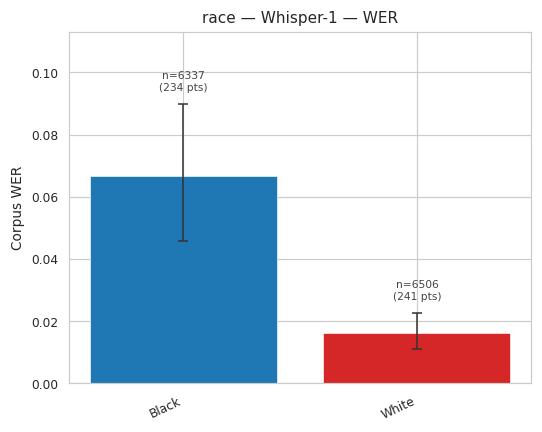

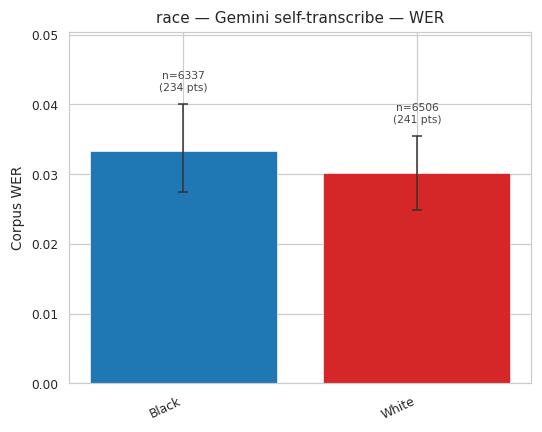

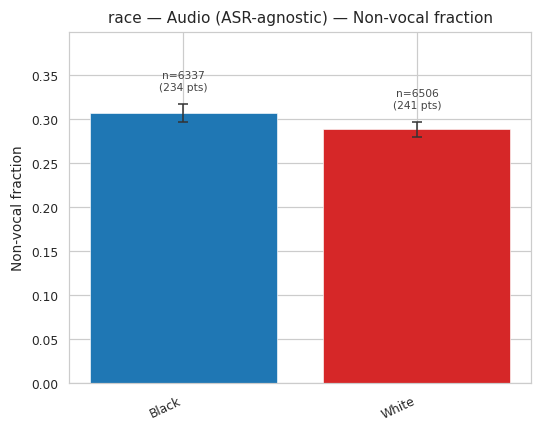

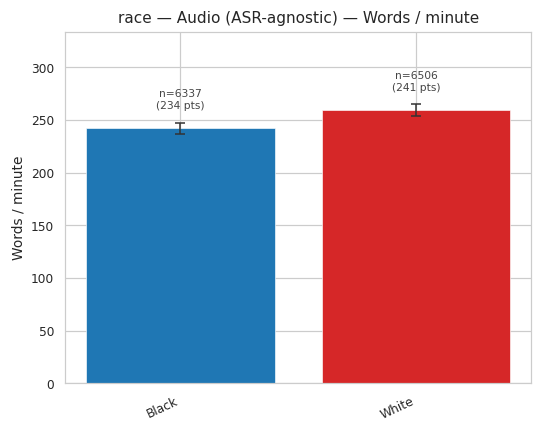

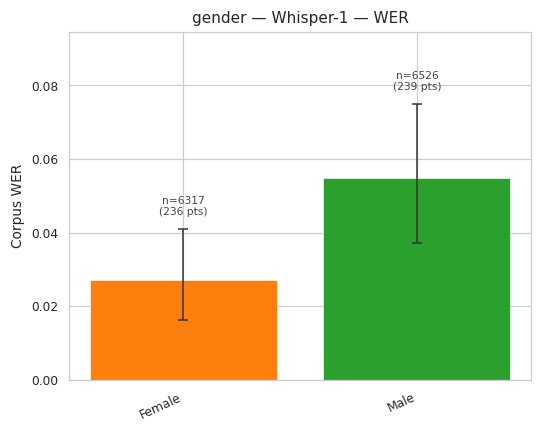

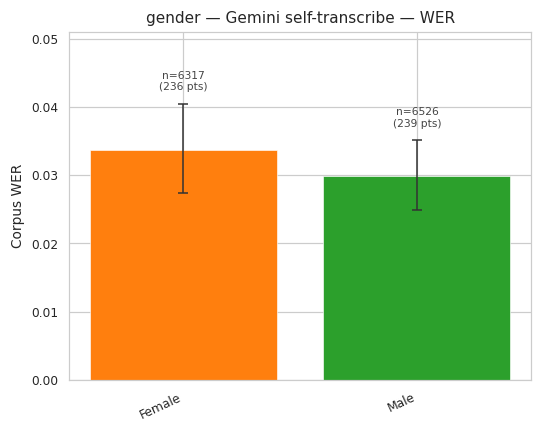

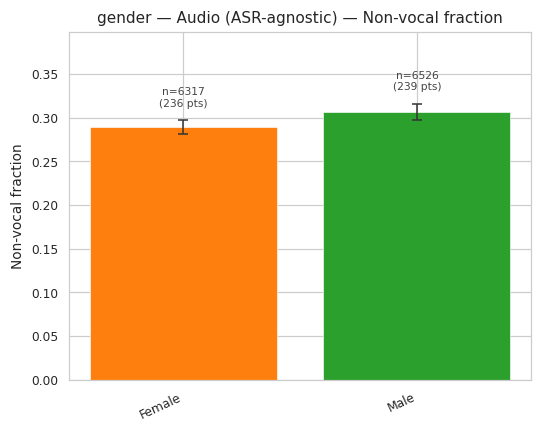

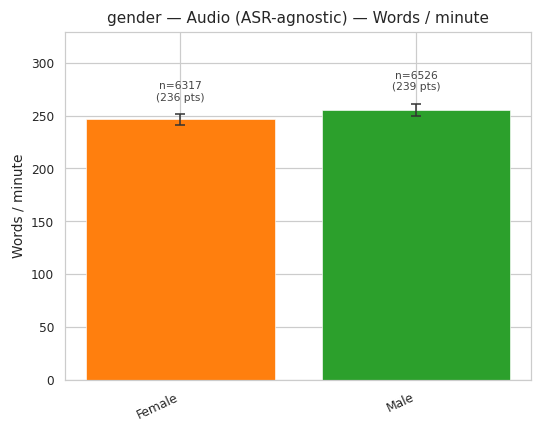

In [15]:
# Inline preview: race + gender (WER per ASR + secondary metrics).
print("=== Inline preview: race + gender ===\n")
for axis_label in ("race", "gender"):
    for asr in ("whisper-1", "gemini-self"):
        plot_metric_axis(wer_by_group, axis_label, asr,
                          metric="wer", ylabel="Corpus WER",
                          save_dir=None, show=True)
    for metric in SECONDARY_METRICS:
        sub = secondary_by_group[secondary_by_group["metric"] == metric]
        plot_metric_axis(sub, axis_label, "audio",
                          metric=metric, ylabel=METRIC_LABEL[metric],
                          save_dir=None, show=True)


## 9. Combined tables (markdown + LaTeX)

One table per `(metric × axis)`. WER tables carry one column-pair per
ASR; secondary-metric tables have a single value column.


In [16]:
def _fmt_ci(p, lo, hi, digits=3):
    if pd.isna(p):
        return "—"
    if pd.isna(lo) or pd.isna(hi):
        return f"{p:.{digits}f}"
    return f"{p:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"


def wer_table_combined(df, axis_label, *, models=("whisper-1", "gemini-self")):
    sub = df[df["axis"] == axis_label].copy()
    if sub.empty:
        return None
    rows = []
    for g in sorted(sub["group"].dropna().unique()):
        row = {"Group": str(g)}
        for a in models:
            r = sub[(sub["asr"] == a) & (sub["group"] == g)]
            if r.empty:
                row[f"{ASR_LABEL[a]} WER [95% CI]"] = "—"
                row[f"{ASR_LABEL[a]} n_clips"] = 0
            else:
                r = r.iloc[0]
                row[f"{ASR_LABEL[a]} WER [95% CI]"] = _fmt_ci(r["point"], r["ci_lo"], r["ci_hi"])
                row[f"{ASR_LABEL[a]} n_clips"] = int(r["n_clips"])
        rows.append(row)
    return pd.DataFrame(rows)


def secondary_table(df, axis_label, metric):
    sub = df[(df["axis"] == axis_label) & (df["metric"] == metric)].copy()
    if sub.empty:
        return None
    rows = []
    for g in sorted(sub["group"].dropna().unique()):
        r = sub[sub["group"] == g].iloc[0]
        rows.append({
            "Group": str(g),
            f"{METRIC_LABEL[metric]} [95% CI]": _fmt_ci(r["point"], r["ci_lo"], r["ci_hi"]),
            "n_clips": int(r["n_clips"]),
            "n_participants": int(r["n_participants"]),
        })
    return pd.DataFrame(rows)


def write_table(tbl, stem):
    if tbl is None or tbl.empty:
        return
    (TBL / f"{stem}.md").write_text(tbl.to_markdown(index=False))
    (TBL / f"{stem}.tex").write_text(
        tbl.to_latex(index=False, escape=True,
                       column_format="l" + "l" * (len(tbl.columns) - 1))
    )


axes = ["race", "gender", "recording_device", "english_l1l2",
        "age", "accent_simplified", "accent", "primary_language"]

n_tables = 0
for axis_label in axes:
    write_table(wer_table_combined(wer_by_group, axis_label),
                f"{axis_label}__wer_by_group__combined")
    n_tables += 1
    for metric in SECONDARY_METRICS:
        write_table(secondary_table(secondary_by_group, axis_label, metric),
                    f"{axis_label}__{metric}__by_group")
        n_tables += 1
print(f"wrote {n_tables} tables (md + LaTeX) to {TBL.relative_to(REPO_ROOT)}/")

# Inline preview
for axis_label in ("race", "gender"):
    print(f"\n=== {axis_label.upper()} — WER ===")
    print(wer_table_combined(wer_by_group, axis_label).to_markdown(index=False))
    for metric in SECONDARY_METRICS:
        print(f"\n=== {axis_label.upper()} — {METRIC_LABEL[metric]} ===")
        print(secondary_table(secondary_by_group, axis_label, metric).to_markdown(index=False))


wrote 24 tables (md + LaTeX) to paper/tables/wer/

=== RACE — WER ===
| Group   | Whisper-1 WER [95% CI]   |   Whisper-1 n_clips | Gemini self-transcribe WER [95% CI]   |   Gemini self-transcribe n_clips |
|:--------|:-------------------------|--------------------:|:--------------------------------------|---------------------------------:|
| Black   | 0.067 [0.046, 0.090]     |                6337 | 0.033 [0.027, 0.040]                  |                             6337 |
| White   | 0.016 [0.011, 0.023]     |                6506 | 0.030 [0.025, 0.035]                  |                             6506 |

=== RACE — Non-vocal fraction ===
| Group   | Non-vocal fraction [95% CI]   |   n_clips |   n_participants |
|:--------|:------------------------------|----------:|-----------------:|
| Black   | 0.307 [0.298, 0.317]          |      6337 |              234 |
| White   | 0.289 [0.280, 0.297]          |      6506 |              241 |

=== RACE — Words / minute ===
| Group   | Words / 

## 10. Output inventory


In [17]:
fig_files = sorted(FIG.glob("*.png"))
tbl_files = sorted(TBL.glob("*.md"))
data_files = [WER_PER_CLIP_CSV, WER_BY_GROUP_CSV, SECONDARY_CSV, SECONDARY_GROUP_CSV]

print(f"{len(fig_files)} PNG (+ matching PDF) figures in {FIG.relative_to(REPO_ROOT)}/")
for f in fig_files:
    print(f"  {f.name}")
print(f"\n{len(tbl_files)} markdown tables (+ LaTeX) in {TBL.relative_to(REPO_ROOT)}/")
for f in tbl_files:
    print(f"  {f.name}")
print(f"\n{len(data_files)} data artifacts:")
for f in data_files:
    line = f"  {f.relative_to(REPO_ROOT)}"
    line += f"  ({f.stat().st_size / 1024:.1f} KB)" if f.exists() else "  (missing!)"
    print(line)


34 PNG (+ matching PDF) figures in paper/figures/wer/
  non_vocal_fraction__accent__audio__by_group.png
  non_vocal_fraction__accent_simplified__audio__by_group.png
  non_vocal_fraction__age__audio__by_group.png
  non_vocal_fraction__english_l1l2__audio__by_group.png
  non_vocal_fraction__gender__audio__by_group.png
  non_vocal_fraction__primary_language__audio__by_group.png
  non_vocal_fraction__race__audio__by_group.png
  non_vocal_fraction__recording_device__audio__by_group.png
  secondary_metric_distributions.png
  wer__accent__gemini-self__by_group.png
  wer__accent__whisper-1__by_group.png
  wer__accent_simplified__gemini-self__by_group.png
  wer__accent_simplified__whisper-1__by_group.png
  wer__age__gemini-self__by_group.png
  wer__age__whisper-1__by_group.png
  wer__english_l1l2__gemini-self__by_group.png
  wer__english_l1l2__whisper-1__by_group.png
  wer__gender__gemini-self__by_group.png
  wer__gender__whisper-1__by_group.png
  wer__primary_language__gemini-self__by_group.pn